# Mean Reversion Strategy: Pair Trading of {s1} vs {s2}

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint
import yfinance as yf

## Investigating pair trading possibilities

Before we start, it's important to verify if our data is stationary before proceeding with the pair trading strategy. 

We can use Engle-Granger method. `coint` function from `statsmodels` can be used to perform the Engle-Granger two-step method for testing cointegration between two time series.

In [38]:
tickers = ['SPY','SCHD','AAPL','MSFT','GOOG','ADBE','EBAY','QCOM','HPQ','NVDA','AMD','IBM','AVGO','SNOW','HPE','PLTR']
WINDOW = {
  "start": "2022-10-01",
  "end": "2026-09-01"
}
TRAIN_WINDOW = {
  "start": "2022-10-01",
  "end": "2025-09-30"
}
TEST_WINDOW = {
  "start": "2025-10-01",
  "end": "2026-09-01"
}
TRAIN_RANGE = slice("2022-10-01", "2025-09-30")
TEST_RANGE = slice("2025-10-01", "2026-09-01")

In [39]:
n = len(tickers)
score_matrix = np.zeros((n, n))
pvalue_matrix = np.ones((n, n))
pairs = []

for i in range(len(tickers)):
    for j in range(i+1, len(tickers)):
        s1 = tickers[i]
        s2 = tickers[j]
        
        # Download historical data for the two stocks
        data1 = yf.Ticker(s1).history(start=TRAIN_WINDOW["start"], end=TRAIN_WINDOW["end"], auto_adjust=True)['Close']
        data2 = yf.Ticker(s2).history(start=TRAIN_WINDOW["start"], end=TRAIN_WINDOW["end"], auto_adjust=True)['Close']
        
        # Align on common index and drop NaNs
        common_index = data1.dropna().index.intersection(data2.dropna().index)
        data1_aligned = data1.loc[common_index]
        data2_aligned = data2.loc[common_index]
        
        # Perform cointegration test
        score, pvalue, _ = coint(data1_aligned, data2_aligned)
        
        score_matrix[i, j] = score
        pvalue_matrix[i, j] = pvalue
        
        if pvalue < 0.05:  # Using a significance level of 0.05
            pairs.append((s1, s2, pvalue))

<Axes: >

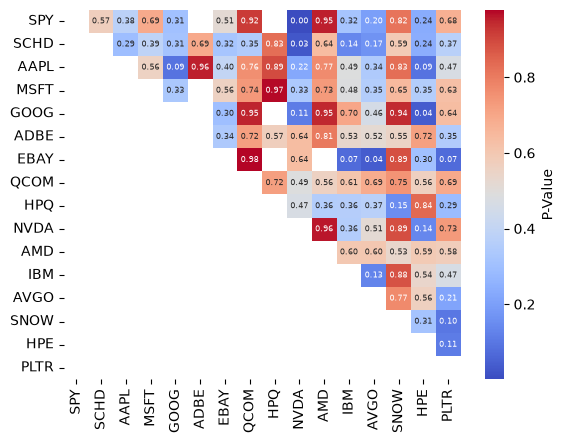

In [40]:
m = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
sns.heatmap(pvalue_matrix, annot=True, annot_kws={"size": 6}, fmt=".2f", xticklabels=tickers, yticklabels=tickers, cmap="coolwarm", cbar_kws={'label': 'P-Value'}, mask=pvalue_matrix >= 0.98)

In [41]:
pairs

[('SPY', 'NVDA', 0.0013962707214561208),
 ('SCHD', 'NVDA', 0.026810962659072984),
 ('GOOG', 'HPE', 0.0385265149793321),
 ('EBAY', 'AVGO', 0.03784385662410112)]

We narrowed down our pairs like the above.
Those pairs are selected based on the p-value of the cointegration test, at a significance level of 0.05. If the p-value is less than 0.05, we reject the null hypothesis (no cointegration) and conclude that the two time series are cointegrated.

Among above pairs, we empirically selected 'EBAY' and 'AVGO' for our pair trading strategy, as it's test results show the best performance among the pairs.

In [42]:
PAIRS = {
  "s1": "EBAY",
  "s2": "AVGO"
}

In [43]:
s1 = yf.Ticker(PAIRS["s1"]).history(
    start=WINDOW["start"],
    end=WINDOW["end"],
    auto_adjust=True,
)
s1.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2022-10-03 00:00:00-04:00,34.381840,35.014749,33.674473,34.642452,8930300,0.0,0.0
2022-10-04 00:00:00-04:00,35.470818,36.466719,35.452203,35.992035,8189800,0.0,0.0
2022-10-05 00:00:00-04:00,35.601116,36.755245,35.535964,36.410866,7290500,0.0,0.0
2022-10-06 00:00:00-04:00,36.252639,36.885548,36.150256,36.196793,6471800,0.0,0.0
2022-10-07 00:00:00-04:00,35.843110,35.908266,34.828594,34.949593,6731600,0.0,0.0


In [44]:
s2 = yf.Ticker(PAIRS["s2"]).history(
    start=WINDOW["start"],
    end=WINDOW["end"],
    auto_adjust=True
)
s2.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2022-10-03 00:00:00-04:00,42.440652,43.546922,42.226199,43.152973,21479000,0.0,0.0
2022-10-04 00:00:00-04:00,44.260173,45.361718,44.010767,45.333378,27277000,0.0,0.0
2022-10-05 00:00:00-04:00,44.642797,46.110891,44.539822,45.800079,18493000,0.0,0.0
2022-10-06 00:00:00-04:00,45.704656,46.262986,45.225682,45.299370,17250000,0.0,0.0
2022-10-07 00:00:00-04:00,44.626727,44.717421,43.364581,43.502510,28425000,0.0,0.0


## Hedge Ratio ($\beta$) and Spread

To compute the spread, we need to first perform a linear regression to find the hedge ratio (beta) of s2 with respect to s1.

In [45]:
X = sm.add_constant(s1[TRAIN_RANGE]['Close'])
y = s2[TRAIN_RANGE]['Close']
model = sm.OLS(y, X).fit()

hedge_ratio = model.params['Close']
intercept = model.params['const']

print(f"Intercept: {intercept:.4f}")
print(f"Hedge Ratio: {hedge_ratio:.4f}")


Intercept: -118.6631
Hedge Ratio: 4.8536


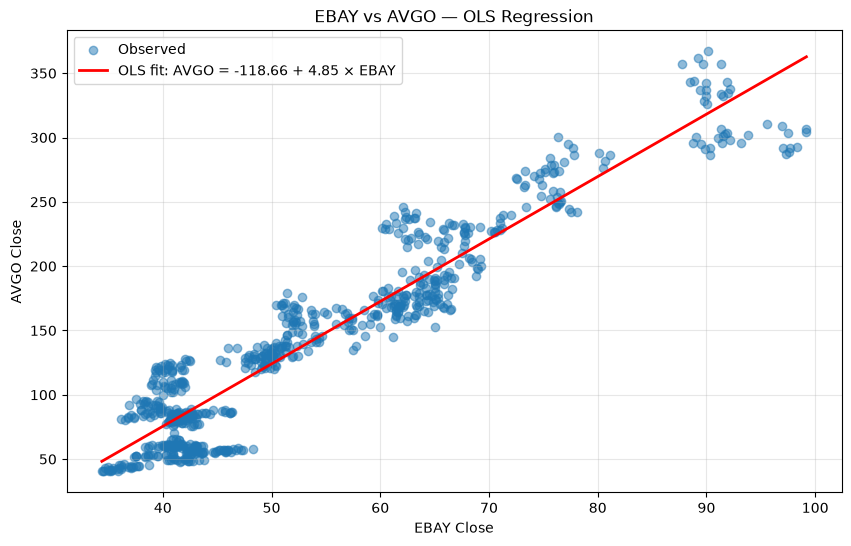

In [46]:
# Predicted MCD prices
y_pred = model.predict(X)

# Plot
plt.figure(figsize=(10, 6))

plt.scatter(s1[TRAIN_RANGE]['Close'], s2[TRAIN_RANGE]['Close'], alpha=0.5, label='Observed')

# Sort X so regression line is drawn correctly
sort_idx = np.argsort(s1[TRAIN_RANGE]['Close'])
plt.plot(
    s1[TRAIN_RANGE]['Close'].iloc[sort_idx],
    y_pred.iloc[sort_idx],
    linewidth=2,
    color='red',
    label=f'OLS fit: {PAIRS["s2"]} = {intercept:.2f} + {hedge_ratio:.2f} × {PAIRS["s1"]}'
)

plt.xlabel(f'{PAIRS["s1"]} Close')
plt.ylabel(f'{PAIRS["s2"]} Close')
plt.title(f'{PAIRS["s1"]} vs {PAIRS["s2"]} — OLS Regression')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

As we calculated the hedge ratio, we can now compute the spread. The spread is calculated as:

$$
Spread_t = Price_{s2,t} - \beta \times Price_{s1,t}
$$

In [47]:
spread = s2['Close'] - hedge_ratio * s1['Close']
spread_mean = spread[TRAIN_RANGE].mean()
spread_std = spread[TRAIN_RANGE].std()

print(f"Spread Mean: {spread_mean:.4f}")
print(f"Spread Std Dev: {spread_std:.4f}")

Spread Mean: -118.6631
Spread Std Dev: 24.3706


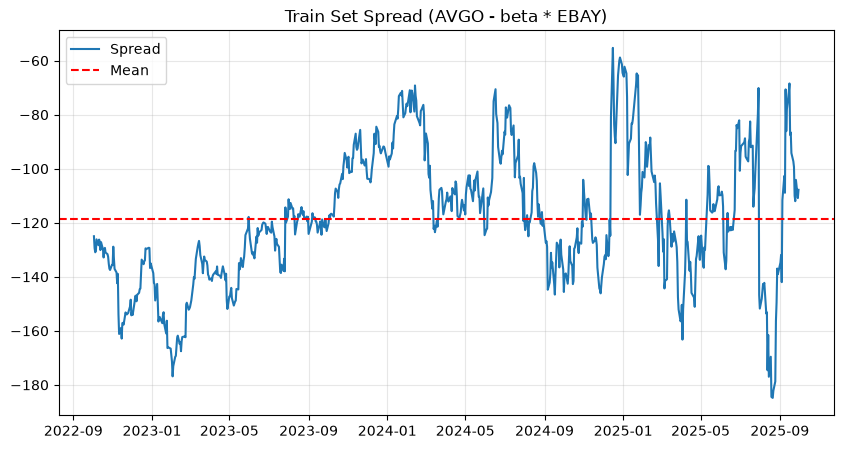

In [48]:
plt.figure(figsize=(10, 5))
plt.plot(spread[TRAIN_RANGE], label='Spread')
plt.axhline(spread_mean, color='red', linestyle='--', label='Mean')
plt.title(f'Train Set Spread ({PAIRS["s2"]} - beta * {PAIRS["s1"]})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Half-life of the Spread

You might want to know how long it takes for the spread to revert back to its mean.

Although it's not a perfect measure, we can use OU process (Ornstein-Uhlenbeck Process) to estimate the half-life of the spread. 

OU process, in this case, is just a linear regression of the change in spread against the lagged spread. The slope of this regression gives us an estimate of the speed of mean reversion.

The half-life is the time it takes for the spread to revert halfway back to its mean.
By this measure, we can get a sense of how long we should expect to hold our positions before the spread reverts back to its mean.

In [49]:
prev_spread = spread[TRAIN_RANGE].shift(1)
d_spread = spread[TRAIN_RANGE] - prev_spread
d_spread = d_spread[1:,]
prev_spread = prev_spread[1:,]
ou = sm.OLS(d_spread, prev_spread.mean() - prev_spread).fit()
theta = ou.params['Close']
halflife=np.log(2)/theta
print(f"Estimated Half-life of the Spread: {halflife:.2f} days")

Estimated Half-life of the Spread: 16.15 days


## Determining Signals & Positions

In [50]:
z_scores = (spread - spread_mean) / spread_std

We calculated Z-score of the spread to identify the entry and exit points for our pair trading strategy. To implement a robust mean-reversion trading strategy, we define a state-machine that holds positions until the spread reverts back to its mean (Z-score crosses 0). This prevents over-trading and premature exits compared to exiting as soon as Z falls below 2.

Our trading rules are:
- **No position (Flat)**:
  - If $Z \ge 2$: Short the spread (Short s2, Long s1) -> Position = -1
  - If $Z \le -2$: Long the spread (Long s2, Short s1) -> Position = 1
- **Long Spread (Position = 1)**:
  - Exit when $Z \ge 0$ (crosses the mean) -> Position = 0
- **Short Spread (Position = -1)**:
  - Exit when $Z \le 0$ (crosses the mean) -> Position = 0

In [105]:
# Hyperparameters
theta_entry = 2.0
theta_exit = 0.5
TRANSACTION_COST_RATE = 0.0010  # 10 bps per trade (commission + slippage)

In [106]:
positions = pd.DataFrame(index=spread.index)
positions['z_scores'] = z_scores

positions['pos_spread'] = 0.0

current_pos = 0

for i in positions.index:
    z = positions.loc[i, 'z_scores']

    if current_pos == 0:
        if z > theta_entry:
            current_pos = -1
        elif z < -theta_entry:
            current_pos = 1

    elif current_pos == 1:
        if z > -theta_exit:
            current_pos = 0

    elif current_pos == -1:
        if z < theta_exit:
            current_pos = 0

    positions.loc[i, 'pos_spread'] = current_pos

positions['pos_s1'] = -hedge_ratio * positions['pos_spread']
positions['pos_s2'] = positions['pos_spread']

positions.head()

,z_scores,pos_spread,pos_s1,pos_s2
Date,,,,
2022-10-03 00:00:00-04:00,-0.259539,0.0,-0.0,0.0
2022-10-04 00:00:00-04:00,-0.438852,0.0,-0.0,0.0
2022-10-05 00:00:00-04:00,-0.503115,0.0,-0.0,0.0
2022-10-06 00:00:00-04:00,-0.481026,0.0,-0.0,0.0
2022-10-07 00:00:00-04:00,-0.306366,0.0,-0.0,0.0


## Backtesting

Now we'll evaluate the performance of our pair trading strategy. To compute correct portfolio returns, we must weight the returns of s1 and s2 by their capital allocations based on the hedge ratio (beta) to ensure beta-neutrality.

- $Position_{s1} = -\beta \times SpreadPosition$
- $Position_{s2} = SpreadPosition$
- $E_{s1} = Position_{s1} \times Price_{s1}$
- $E_{s2} = Position_{s2} \times Price_{s2}$
- $G = |E_{s1}| + |E_{s2}|$
- $w_{s1} = \frac{E_{s1}}{G}$
- $w_{s2} = \frac{E_{s2}}{G}$
- $R_P = w_{s1} \times R_{s1} + w_{s2} \times R_{s2}$

In [107]:
portfolio_return = pd.DataFrame(index=spread.index)
portfolio_return['position_s1'] = positions['pos_s1']
portfolio_return['position_s2'] = positions['pos_s2']

portfolio_return['price_s1'] = s1['Close']
portfolio_return['price_s2'] = s2['Close']

portfolio_return['exposure_s1'] = portfolio_return['position_s1'] * portfolio_return['price_s1']
portfolio_return['exposure_s2'] = portfolio_return['position_s2'] * portfolio_return['price_s2']

portfolio_return['gross_exposure'] = np.abs(portfolio_return['exposure_s1']) + np.abs(portfolio_return['exposure_s2'])

portfolio_return['weight_s1'] = np.where(
    portfolio_return['gross_exposure'] != 0,
    portfolio_return['exposure_s1'] / portfolio_return['gross_exposure'],
    0.0
)

portfolio_return['weight_s2'] = np.where(
    portfolio_return['gross_exposure'] != 0,
    portfolio_return['exposure_s2'] / portfolio_return['gross_exposure'],
    0.0
)

portfolio_return['gross_return'] = (portfolio_return['weight_s1'].shift() * s1['Close'].pct_change()) + (portfolio_return['weight_s2'].shift() * s2['Close'].pct_change())

portfolio_return['turnover'] = portfolio_return['position_s1'].diff().abs() + portfolio_return['position_s2'].diff().abs()

portfolio_return['transaction_cost'] = TRANSACTION_COST_RATE * portfolio_return['turnover']

portfolio_return['net_return'] = portfolio_return['gross_return'] - portfolio_return['transaction_cost']

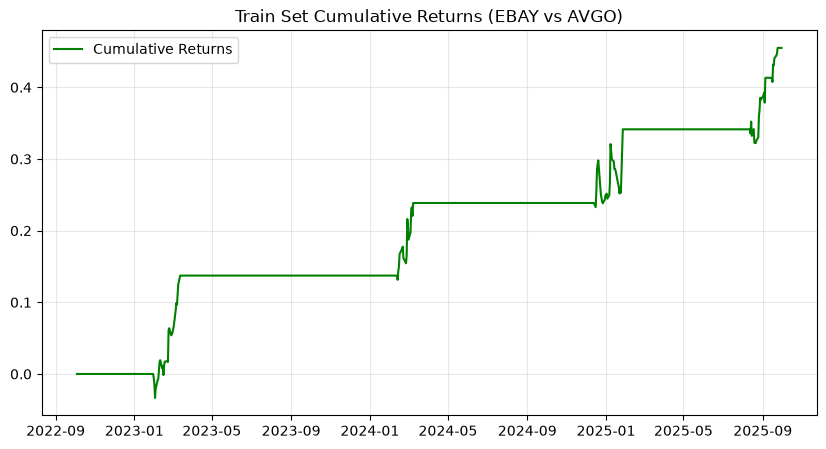

In [108]:
pnl_train = portfolio_return['net_return'][TRAIN_RANGE].cumsum()
plt.figure(figsize=(10, 5))
plt.plot(pnl_train, label='Cumulative Returns', color='green')
plt.title(f'Train Set Cumulative Returns ({PAIRS["s1"]} vs {PAIRS["s2"]})')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [109]:
r_train = portfolio_return['net_return'][TRAIN_RANGE]
sharpe_train = r_train.mean() / (r_train.std() + 1e-12) * np.sqrt(252)
print(f"Train Set Sharpe Ratio: {sharpe_train:.4f}")

mdd_train = (pnl_train.cummax() - pnl_train).max()
drawdown_trough_train = (pnl_train.cummax() - pnl_train).idxmax()
drawdown_peak_train = pnl_train[:drawdown_trough_train].idxmax()
mdd_duration_train = drawdown_trough_train - drawdown_peak_train
print(f"Train Set Maximum Drawdown: {mdd_train:.4f}")
print(f"Train Set Maximum Drawdown Duration: {mdd_duration_train.days} days")

Train Set Sharpe Ratio: 1.5172
Train Set Maximum Drawdown: 0.0690
Train Set Maximum Drawdown Duration: 14 days


Take a look for the cell above: Typical sharpe ratio computation looks like:

$$
\text{Sharpe Ratio} = \frac{R_P - R_f}{\sigma_P}
$$

But in our case, we can assume the risk-free rate is 0, so we can simplify the formula to:

$$
\text{Sharpe Ratio} = \frac{R_P}{\sigma_P}
$$

The reason we assume the risk-free rate is 0 is that we assume we open our positions with our own capital, and we don't borrow money to open our positions. If we were to borrow money, we would have to pay interest on the borrowed money, which would be the risk-free rate. But since we are not borrowing money, we can assume the risk-free rate is 0.

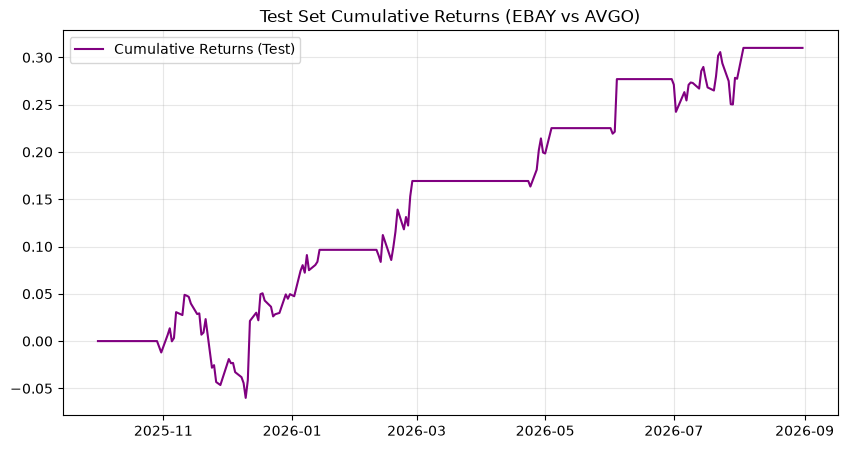

In [110]:
pnl_test = portfolio_return['net_return'][TEST_RANGE].cumsum()
plt.figure(figsize=(10, 5))
plt.plot(pnl_test, label='Cumulative Returns (Test)', color='purple')
plt.title(f'Test Set Cumulative Returns ({PAIRS["s1"]} vs {PAIRS["s2"]})')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [111]:
r_test = portfolio_return['net_return'][TEST_RANGE]
sharpe_test = r_test.mean() / (r_test.std() + 1e-12) * np.sqrt(252)
print(f"Test Set Sharpe Ratio: {sharpe_test:.4f}")

mdd_test = (pnl_test.cummax() - pnl_test).max()
drawdown_trough_test = (pnl_test.cummax() - pnl_test).idxmax()
drawdown_peak_test = pnl_test[:drawdown_trough_test].idxmax()
mdd_duration_test = drawdown_trough_test - drawdown_peak_test
print(f"Test Set Maximum Drawdown: {mdd_test:.4f}")
print(f"Test Set Maximum Drawdown Duration: {mdd_duration_test.days} days")

Test Set Sharpe Ratio: 1.8958
Test Set Maximum Drawdown: 0.1090
Test Set Maximum Drawdown Duration: 29 days
